Reading data

In [ ]:
import pandas as pd

data = pd.read_excel(r"C:\Users\hrush\Desktop\BTP\output_data_final_discharge.xlsx")

print(data.head())


   Hex  Tex  Crate part1  AverageSlopeDiffSOC        Tmax        Tend  \
0   20  300      1   5.6             0.000003  304.430474  304.430474   
1   20  300      2   5.6             0.000003  305.949342  305.948865   
2   20  300      3   5.6             0.000003  308.515678  308.515678   
3   20  300      4   5.6             0.000003  312.106774  312.106774   
4   20  300      5   5.6             0.000003  315.875745  315.489200   

  Risk_level Risk_status  
0        LOW  Increasing  
1        LOW    Stagnant  
2        LOW  Increasing  
3        LOW  Increasing  
4        LOW    Stagnant  


Split data into testing and training set

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


features = ['Hex', 'Tex', 'AverageSlopeDiffSOC', 'Crate']
target = 'Tmax'
risk_level_target = 'Risk_level'  

X = data[features]
y = data[target]
risk_level = data[risk_level_target]

X_train_val, X_test, y_train_val, y_test, risk_level_train_val, risk_level_test = train_test_split(X, y, risk_level, test_size=0.1, random_state=32)

X_train, X_val, y_train, y_val, risk_level_train, risk_level_val = train_test_split(X_train_val, y_train_val, risk_level_train_val, test_size=0.111111, random_state=39)

print("Training set shape:", X_train.shape, y_train.shape, risk_level_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape, risk_level_val.shape)
print("Testing set shape:", X_test.shape, y_test.shape, risk_level_test.shape)


Training set shape: (370, 4) (370,) (370,)
Validation set shape: (47, 4) (47,) (47,)
Testing set shape: (47, 4) (47,) (47,)


In [33]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

Random forest model

In [34]:
rf_model = RandomForestRegressor(random_state=25)
rf_model.fit(X_train, y_train)
rf_y_pred_test = rf_model.predict(X_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_y_pred_test))
rf_mse_test = mean_squared_error(y_test, rf_y_pred_test)
print(f"Random Forest: RMSE_test = {rf_rmse_test:.2f}, MSE_test = {rf_mse_test:.2f}")

Random Forest: RMSE_test = 1.70, MSE_test = 2.89


SVR Model

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
svr_y_pred_test = svr_model.predict(X_test_scaled)
svr_rmse_test = np.sqrt(mean_squared_error(y_test, svr_y_pred_test))
svr_mse_test = mean_squared_error(y_test, svr_y_pred_test)
print(f"SVR with MaxAbsScaler: RMSE_test = {svr_rmse_test:.2f}, MSE_test = {svr_mse_test:.2f}")



SVR with MaxAbsScaler: RMSE_test = 9.94, MSE_test = 98.77


Gradient Boosting

In [36]:
xgb_model = XGBRegressor(random_state=32)
xgb_model.fit(X_train, y_train)
xgb_y_pred_test = xgb_model.predict(X_test)
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_y_pred_test))
xgb_mse_test = mean_squared_error(y_test, xgb_y_pred_test)
print(f"XGBoost: RMSE_test = {xgb_rmse_test:.2f}, MSE_test = {xgb_mse_test:.2f}")

XGBoost: RMSE_test = 1.37, MSE_test = 1.88


ANN

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import mean_squared_error


scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


ann_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])


ann_model.compile(optimizer='adam', loss='mean_squared_error')


ann_model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, verbose=0)


ann_y_pred_test = ann_model.predict(X_test_scaled).flatten()
ann_rmse_test = np.sqrt(mean_squared_error(y_test, ann_y_pred_test))
ann_mse_test = mean_squared_error(y_test, ann_y_pred_test)
print(f"Custom ANN with MaxAbsScaler: RMSE_test = {ann_rmse_test:.2f}, MSE_test = {ann_mse_test:.2f}")


C:\Users\hrush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000025F72C88280> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Custom ANN with MaxAbsScaler: RMSE_test = 1.96, MSE_test = 3.83


SVR scatterplots

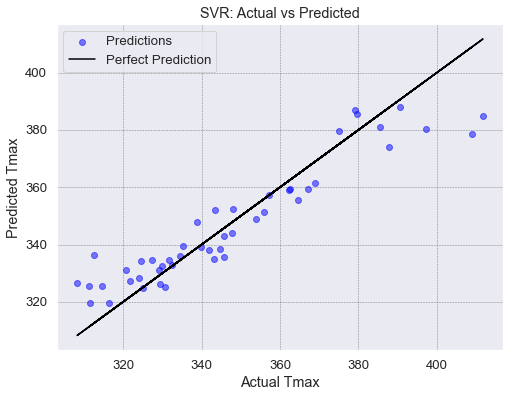

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_y_pred_test, color='blue', alpha=0.5, label='Predictions')
plt.plot(y_test, y_test, color='black', linestyle='-', label='Perfect Prediction')
plt.title('SVR: Actual vs Predicted')
plt.xlabel('Actual Tmax')
plt.ylabel('Predicted Tmax')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()


ANN Scatterplot

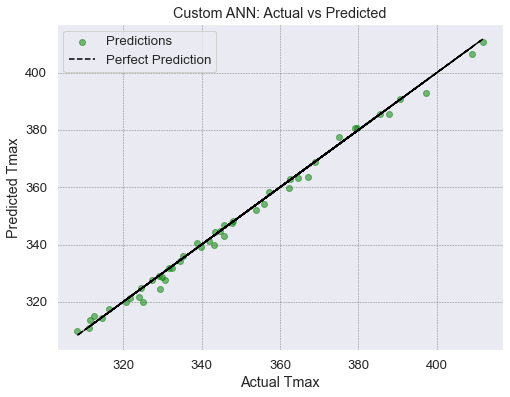

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.scatter(y_test, ann_y_pred_test, color='green', alpha=0.5, label='Predictions')
plt.plot(y_test, y_test, color='black', linestyle='--', label='Perfect Prediction')
plt.title('Custom ANN: Actual vs Predicted')
plt.xlabel('Actual Tmax')
plt.ylabel('Predicted Tmax')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()


Scatterplot for XG Boost model

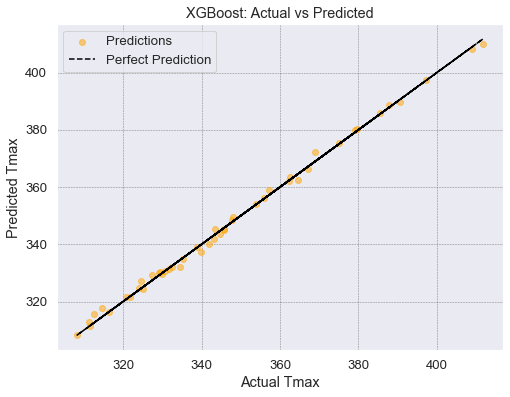

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_y_pred_test, color='orange', alpha=0.5, label='Predictions')
plt.plot(y_test, y_test, color='black', linestyle='--', label='Perfect Prediction')
plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Actual Tmax')
plt.ylabel('Predicted Tmax')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()


Scatterplot for Randomforests

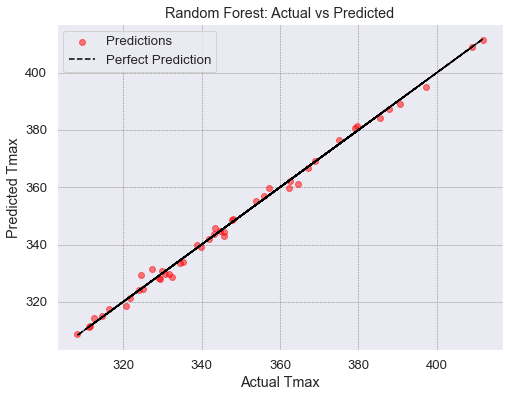

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_y_pred_test, color='red', alpha=0.5, label='Predictions')
plt.plot(y_test, y_test, color='black', linestyle='--', label='Perfect Prediction')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Tmax')
plt.ylabel('Predicted Tmax')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


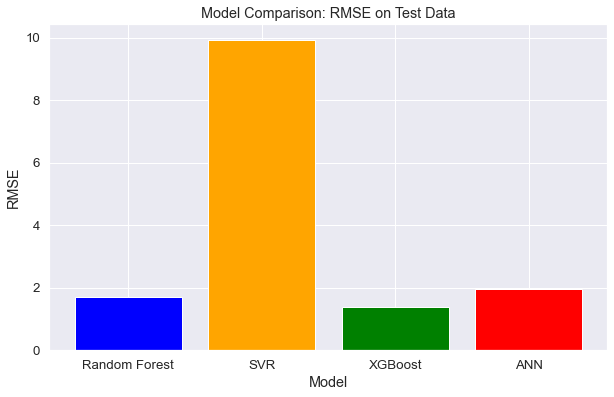

In [ ]:
models = {
    'Random Forest': rf_model,
    'SVR': svr_model,
    'XGBoost': xgb_model,
    'ANN': ann_model
}


model_rmse = {}
for name, model in models.items():
    if name in ['SVR', 'ANN']:  
        y_pred = model.predict(scaler.transform(X_test))
    else:
        y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    model_rmse[name] = rmse


plt.figure(figsize=(10, 6))
plt.bar(model_rmse.keys(), model_rmse.values(), color=['blue', 'orange', 'green', 'red'])
plt.title("Model Comparison: RMSE on Test Data")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()


In [ ]:

def assign_risk_level(Tmax):
    risk_levels = []
    for value in Tmax:
        if value < 330:
            risk_levels.append('LOW')
        elif 330 <= value < 360:
            risk_levels.append('MODERATE')
        elif 360 <= value < 390:
            risk_levels.append('HIGH')
        else:
            risk_levels.append('VERY HIGH')
    return risk_levels


rf_risk_level = assign_risk_level(rf_y_pred_test)
svr_risk_level = assign_risk_level(svr_y_pred_test)
xgb_risk_level = assign_risk_level(xgb_y_pred_test)
ann_risk_level = assign_risk_level(ann_y_pred_test)

print("Random Forest Risk Level:", rf_risk_level)
print("SVR Risk Level:", svr_risk_level)
print("XGBoost Risk Level:", xgb_risk_level)
print("ANN Risk Level:", ann_risk_level)


Random Forest Risk Level: ['HIGH', 'HIGH', 'LOW', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'LOW', 'LOW', 'LOW', 'MODERATE', 'MODERATE', 'HIGH', 'MODERATE', 'HIGH', 'MODERATE', 'LOW', 'MODERATE', 'HIGH', 'HIGH', 'HIGH', 'MODERATE', 'VERY HIGH', 'HIGH', 'LOW', 'LOW', 'LOW', 'LOW', 'MODERATE', 'LOW', 'VERY HIGH', 'MODERATE', 'MODERATE', 'VERY HIGH', 'LOW', 'LOW', 'MODERATE', 'LOW', 'LOW', 'MODERATE', 'LOW', 'LOW']
SVR Risk Level: ['MODERATE', 'HIGH', 'LOW', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'LOW', 'LOW', 'LOW', 'MODERATE', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'MODERATE', 'MODERATE', 'HIGH', 'HIGH', 'HIGH', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'LOW', 'LOW', 'MODERATE', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'HIGH', 'MODERATE', 'MODERATE', 'MODERATE', 'LOW', 'LOW', 'MODERATE', 'LOW', 'LOW']
XGBoost Risk Level: ['HIGH', 'HIGH'

In [ ]:
def build_classification_matrix(actual, predicted):
    categories = ['LOW', 'MODERATE', 'HIGH', 'VERY HIGH']
    classification_matrix = {actual_category: {predicted_category: 0 for predicted_category in categories} for actual_category in categories}
    
    for actual_value, predicted_value in zip(actual, predicted):
        classification_matrix[actual_value][predicted_value] += 1
    
    return classification_matrix


matrix1 = build_classification_matrix(risk_level_test,rf_risk_level)
matrix2 = build_classification_matrix(risk_level_test,svr_risk_level)
matrix3= build_classification_matrix(risk_level_test,xgb_risk_level)
matrix4 = build_classification_matrix(risk_level_test,ann_risk_level)


for actual_category in matrix1:
    print(actual_category, matrix1[actual_category])
for actual_category in matrix2:
    print(actual_category, matrix2[actual_category])
for actual_category in matrix3:
    print(actual_category, matrix3[actual_category])
for actual_category in matrix4:
    print(actual_category, matrix4[actual_category])        

LOW {'LOW': 13, 'MODERATE': 1, 'HIGH': 0, 'VERY HIGH': 0}
MODERATE {'LOW': 3, 'MODERATE': 16, 'HIGH': 0, 'VERY HIGH': 0}
HIGH {'LOW': 0, 'MODERATE': 1, 'HIGH': 9, 'VERY HIGH': 0}
VERY HIGH {'LOW': 0, 'MODERATE': 0, 'HIGH': 1, 'VERY HIGH': 3}
LOW {'LOW': 9, 'MODERATE': 5, 'HIGH': 0, 'VERY HIGH': 0}
MODERATE {'LOW': 1, 'MODERATE': 18, 'HIGH': 0, 'VERY HIGH': 0}
HIGH {'LOW': 0, 'MODERATE': 4, 'HIGH': 6, 'VERY HIGH': 0}
VERY HIGH {'LOW': 0, 'MODERATE': 0, 'HIGH': 4, 'VERY HIGH': 0}
LOW {'LOW': 12, 'MODERATE': 2, 'HIGH': 0, 'VERY HIGH': 0}
MODERATE {'LOW': 1, 'MODERATE': 18, 'HIGH': 0, 'VERY HIGH': 0}
HIGH {'LOW': 0, 'MODERATE': 0, 'HIGH': 10, 'VERY HIGH': 0}
VERY HIGH {'LOW': 0, 'MODERATE': 0, 'HIGH': 1, 'VERY HIGH': 3}
LOW {'LOW': 14, 'MODERATE': 0, 'HIGH': 0, 'VERY HIGH': 0}
MODERATE {'LOW': 2, 'MODERATE': 17, 'HIGH': 0, 'VERY HIGH': 0}
HIGH {'LOW': 0, 'MODERATE': 1, 'HIGH': 9, 'VERY HIGH': 0}
VERY HIGH {'LOW': 0, 'MODERATE': 0, 'HIGH': 0, 'VERY HIGH': 4}


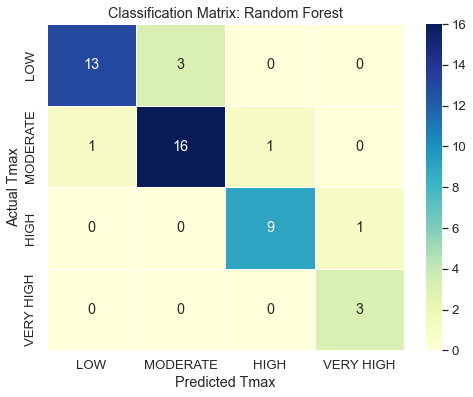

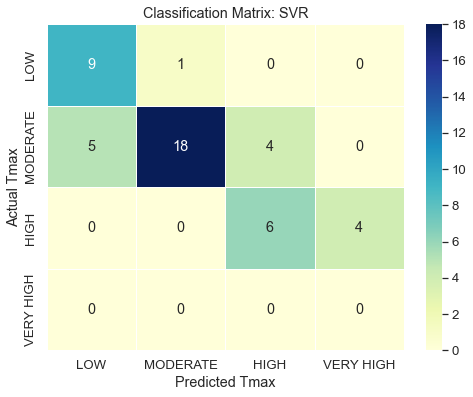

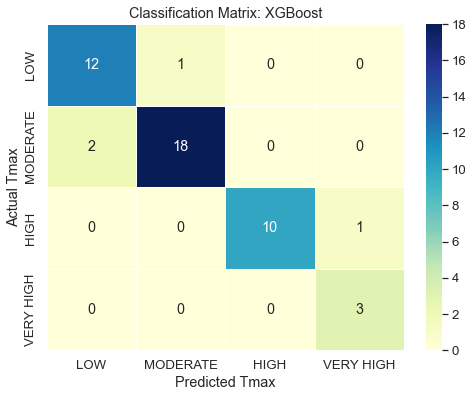

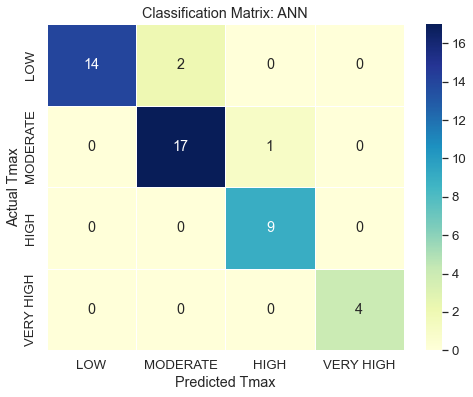

In [ ]:
import seaborn as sns


matrices = [matrix1, matrix2, matrix3, matrix4]
model_names = ['Random Forest', 'SVR', 'XGBoost', 'ANN']


for matrix, model_name in zip(matrices, model_names):
    df = pd.DataFrame(matrix)
    
    sns.set(font_scale=1.2)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=True, cmap="YlGnBu", fmt="d", linewidths=.5)
    plt.title(f'Classification Matrix: {model_name}')
    plt.xlabel('Predicted Tmax')
    plt.ylabel('Actual Tmax')
    plt.show()
